In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

In [48]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(PROCESSED_DIR / "X_train.npy")
X_val = np.load(PROCESSED_DIR / "X_val.npy")

y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_val = np.load(PROCESSED_DIR / "y_val.npy")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1168, 301)
X_val: (292, 301)
y_train: (1168,)
y_val: (292,)


In [49]:
# Our target SalePrice is measured in DOLLARS and has relatively large values 
# That's why we are scaling the SalePrice by 100,000 for numerical stability 
TARGET_SCALE = 100_000.0

y_train_scaled = y_train / TARGET_SCALE
y_val_scaled = y_val / TARGET_SCALE

In [50]:
n_samples, n_features = X_train.shape

# m -> Coefficients
weights = np.zeros(n_features)
# c -> Intercept
bias = 0.0

print("Number of samples:", n_samples)
print("Number of features:", n_features)
print("Initial bias:", bias)
print("Weight shape:", weights.shape)

Number of samples: 1168
Number of features: 301
Initial bias: 0.0
Weight shape: (301,)


In [51]:
def predict(X, weights, bias):
    return X @ weights + bias

In [52]:
# This is the Error / Loss / Cost function that we have used here is MSE (Mean Squared Error)
def compute_cost(y_true, y_pred):
    errors = y_true - y_pred
    mse = np.mean(errors ** 2)

    return mse

In [53]:
def compute_gradients(X, y_true, weights, bias):
    n_samples = X.shape[0]
    y_pred = predict(X, weights, bias)

    errors = y_true - y_pred
    dw = -(2 / n_samples) * (X.T @ errors)
    db = -(2 / n_samples) * np.sum(errors)

    return dw, db

In [54]:
dw, db = compute_gradients(X_train, y_train_scaled, weights, bias)
print("Gradient Shape: ", dw.shape)
print("Bias gradient: ", db)

Gradient Shape:  (301,)
Bias gradient:  -3.628830839041096


In [55]:
def gradient_descent_update(weights, bias, dw, db, learning_rate):
    weights = weights - (learning_rate * dw)
    bias = bias - (learning_rate * db)

    return weights, bias

In [56]:
learning_rate = 0.01

updated_weights, updated_bias = gradient_descent_update(weights, bias, dw, db, learning_rate)

print("Updated Bias: ", updated_bias)
print("First 5 updated weights:", updated_weights[:5])

Updated Bias:  0.03628830839041096
First 5 updated weights: [-0.00136051  0.00482161  0.00411181  0.01213376 -0.00114905]


In [57]:
def train_batch_gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
    n_samples, n_features = X.shape

    weights = np.zeros(n_features)
    bias = 0.0

    loss_history = []

    for iteration in range(n_iterations):
        # Prediction using intial weights and bias
        y_pred = predict(X, weights, bias)

        # Calculate current cost
        cost = compute_cost(y, y_pred)

        loss_history.append(cost)

        # Calculate gradients using all samples
        dw, db = compute_gradients(X, y, weights, bias)

        # Update weights and bias
        weights, bias = gradient_descent_update(weights, bias, dw, db, learning_rate)

    final_predictions = predict(X, weights, bias)
    final_cost = compute_cost(y, final_predictions)
    loss_history.append(final_cost)

    return weights, bias, loss_history

In [58]:
bgd_weights, bgd_bias, bgd_loss_history = train_batch_gradient_descent(X_train, y_train_scaled, learning_rate=0.01, n_iterations=1000)

print("Training completed")
print("Final training MSE:", bgd_loss_history[-1])
print("Learned bias:", bgd_bias)

Training completed
Final training MSE: 0.06955527146964674
Learned bias: 0.09831180882291306


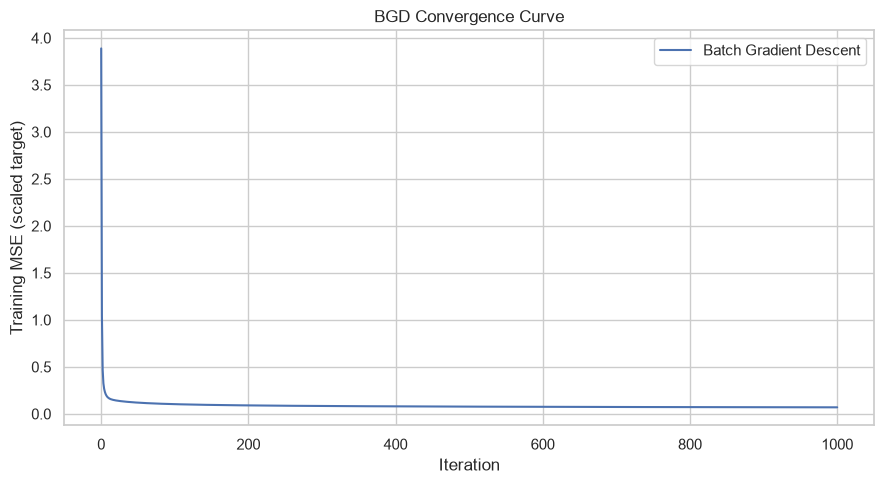

In [59]:
plt.figure(figsize=(9, 5))

plt.plot(
    bgd_loss_history,
    label="Batch Gradient Descent"
)

plt.xlabel("Iteration")
plt.ylabel("Training MSE (scaled target)")
plt.title("BGD Convergence Curve")

plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "bgd_convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
y_train_pred_scaled = predict(X_train, bgd_weights, bgd_bias)

y_val_pred_scaled = predict(X_val, bgd_weights, bgd_bias)

y_train_pred = y_train_pred_scaled * TARGET_SCALE
y_val_pred = y_val_pred_scaled * TARGET_SCALE

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

In [62]:
bgd_train_metrics = evaluate_regression(y_train, y_train_pred)

bgd_val_metrics = evaluate_regression(y_val, y_val_pred)

bgd_results = pd.DataFrame(
    [bgd_train_metrics, bgd_val_metrics],
    index=["Train", "Validation"]
)

bgd_results

,MAE,MSE,RMSE,R2
Train,15944.307864,6.955527e+08,26373.333401,0.883386
Validation,19247.252799,9.697741e+08,31141.196158,0.873568


In [63]:
ols_results = pd.read_csv(
    EXPERIMENTS_DIR / "ols_baseline_metrics.csv",
    index_col=0
)

comparison = pd.DataFrame({
    "OLS": ols_results.loc["Validation"],
    "BGD": pd.Series(bgd_val_metrics)
})

comparison

,OLS,BGD
MAE,2.112545e+04,1.924725e+04
MSE,4.275240e+09,9.697741e+08
RMSE,6.538532e+04,3.114120e+04
R2,4.426261e-01,8.735681e-01


In [64]:
print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

print("Training target shape:", y_train.shape)
print("Validation target shape:", y_val.shape)

print("BGD validation R2:",
      r2_score(y_val, y_val_pred))

print("OLS validation R2:",
      ols_results.loc["Validation", "R2"])

Training shape: (1168, 301)
Validation shape: (292, 301)
Training target shape: (1168,)
Validation target shape: (292,)
BGD validation R2: 0.8735680762493558
OLS validation R2: 0.4426260951994356


In [65]:
bgd_train_pred = predict(X_train, bgd_weights, bgd_bias) * TARGET_SCALE

bgd_val_pred = predict(X_val, bgd_weights, bgd_bias) * TARGET_SCALE

comparison = pd.DataFrame({
    "Model": ["OLS", "BGD"],
    "Train R2": [
        ols_results.loc["Train", "R2"],
        r2_score(y_train, bgd_train_pred)
    ],
    "Validation R2": [
        ols_results.loc["Validation", "R2"],
        r2_score(y_val, bgd_val_pred)
    ],
    "Train RMSE": [
        ols_results.loc["Train", "RMSE"],
        np.sqrt(mean_squared_error(y_train, bgd_train_pred))
    ],
    "Validation RMSE": [
        ols_results.loc["Validation", "RMSE"],
        np.sqrt(mean_squared_error(y_val, bgd_val_pred))
    ]
})

comparison

,Model,Train R2,Validation R2,Train RMSE,Validation RMSE
0,OLS,0.940085,0.442626,18904.114100,65385.316924
1,BGD,0.883386,0.873568,26373.333401,31141.196158


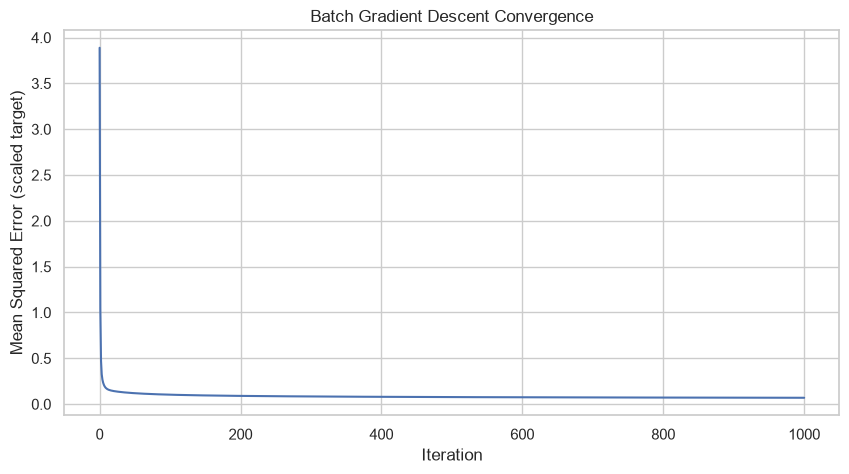

In [66]:
plt.figure(figsize=(10, 5))

plt.plot(bgd_loss_history)

plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (scaled target)")
plt.title("Batch Gradient Descent Convergence")

plt.grid(True)
plt.show()

### Conclusion

In this notebook, Batch Gradient Descent was implemented from scratch using NumPy to understand the optimization process behind Linear Regression.

The implementation covered:

- Parameter initialization using zero weights and bias.
- Mean Squared Error (MSE) as the cost function.
- Analytical computation of gradients with respect to weights and bias.
- Iterative parameter updates using the learning rate.
- Loss tracking to analyze optimization behavior.
- Evaluation using MAE, MSE, RMSE, and R².
- Comparison against the Ordinary Least Squares (OLS) baseline implemented using Scikit-learn.

### Key Learnings

1. **Optimization:** Batch Gradient Descent updates model parameters using gradients calculated over the complete training dataset.

2. **Learning Rate:** The learning rate significantly affects convergence. An excessively large learning rate can cause numerical instability and divergence.

3. **Feature Scaling:** Standardizing numerical features helps improve the stability and efficiency of gradient-based optimization.

4. **Target Scaling:** Scaling the target variable helps maintain manageable gradient magnitudes during training. Predictions must be converted back to the original scale before calculating evaluation metrics.

5. **Convergence:** The loss curve provides insight into whether the optimization process is progressing toward a stable solution.

6. **Model Evaluation:** Comparing training and validation metrics helps assess model fit and generalization. Differences between OLS and BGD should be investigated through convergence analysis rather than assuming one optimizer is universally superior.

### Final Takeaway

Batch Gradient Descent provides a fundamental understanding of how machine learning models learn parameters through iterative optimization. Although OLS provides a direct least-squares solution for Linear Regression, BGD demonstrates the optimization principles that extend to more complex machine learning and deep learning models.

The next notebook will implement **Stochastic Gradient Descent (SGD)**, where parameters are updated using one training sample at a time, allowing us to study the effects of noisy gradient estimates and update frequency.